# Preprocessing Rct/Re and State of Health (SOH) Calculation

This notebook handles the preprocessing of Charge Transfer Resistance (Rct) and Electrolyte Resistance (Re). It also calculates the State of Health (SOH) based on the discharge capacity.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# directory paths for exporting and creating data
metadata_path = './metadata.csv'
impedance_final_path = './processed_data/cleaned_impedance_metadata.csv'
soh_table_path = './processed_data/soh_calculations.csv'

## 1. Data Loading

In [8]:
# Load metadata

df = pd.read_csv(metadata_path)

# Display basic info
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 7565 non-null   str  
 1   start_time           7565 non-null   str  
 2   ambient_temperature  7565 non-null   int64
 3   battery_id           7565 non-null   str  
 4   test_id              7565 non-null   int64
 5   uid                  7565 non-null   int64
 6   filename             7565 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   1956 non-null   str  
 9   Rct                  1956 non-null   str  
dtypes: int64(3), str(7)
memory usage: 591.1 KB
None


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


## 2. Rct and Re Preprocessing

In [9]:
# Filter for impedance measurements
impedance_df = df[df['type'] == 'impedance'].copy()

# Convert Re and Rct to numeric, forcing errors to NaNs
impedance_df['Re'] = pd.to_numeric(impedance_df['Re'], errors='coerce')
impedance_df['Rct'] = pd.to_numeric(impedance_df['Rct'], errors='coerce')

print(f"Original impedance records: {len(impedance_df)}")

# Drop rows with NaN in Re or Rct
impedance_cleaned = impedance_df.dropna(subset=['Re', 'Rct'])
print(f"Records after dropping NaNs: {len(impedance_cleaned)}")

Original impedance records: 1956
Records after dropping NaNs: 1947


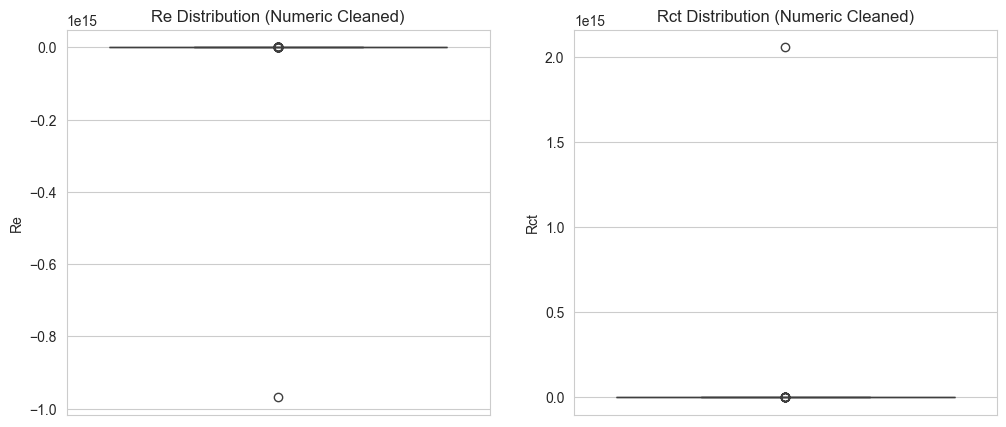

In [10]:
# Visualizing distributions before outlier removal
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=impedance_cleaned['Re'])
plt.title('Re Distribution (Numeric Cleaned)')

plt.subplot(1, 2, 2)
sns.boxplot(y=impedance_cleaned['Rct'])
plt.title('Rct Distribution (Numeric Cleaned)')
plt.show()

In [11]:
# Outlier Removal Strategy
# We'll remove non-positive values and extreme outliers using IQR method

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound) & (data[column] > 0)]

impedance_final = remove_outliers_iqr(impedance_cleaned, 'Re')
impedance_final = remove_outliers_iqr(impedance_final, 'Rct')

print(f"Records after outlier removal: {len(impedance_final)}")

Records after outlier removal: 1907


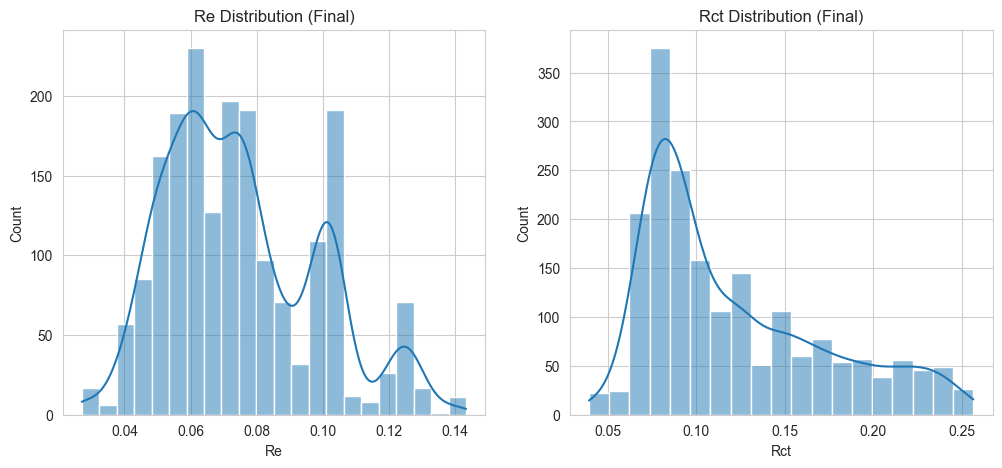

In [12]:
# Visualizing distributions after outlier removal
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(impedance_final['Re'], kde=True)
plt.title('Re Distribution (Final)')

plt.subplot(1, 2, 2)
sns.histplot(impedance_final['Rct'], kde=True)
plt.title('Rct Distribution (Final)')
plt.show()

## 3. State of Health (SOH) Calculation

In [17]:
# Filter for discharge cycles
discharge_df = df[df['type'] == 'discharge'].copy()

# Convert Capacity to numeric
discharge_df['Capacity'] = pd.to_numeric(discharge_df['Capacity'], errors='coerce')

# Drop NaNs
discharge_df = discharge_df.dropna(subset=['Capacity'])

# Nominal Capacity Assumption (Ah)
# I will change this later to take the capacity of the first cycle of some battery
NOMINAL_CAPACITY = 2.0

# Cleaning: Remove Capacity values that are likely errors (e.g., 0 or very close to 0 unless it's end of life)
# Checking for extreme low values first
print("Capacity summary stats:")
print(discharge_df['Capacity'].describe())

# Filtering out 0 capacity which likely indicates sensor error or failed test run rather than dead battery
discharge_cleaned = discharge_df[discharge_df['Capacity'] > 0.0].copy()

print(f"\nDropped {len(discharge_df) - len(discharge_cleaned)} rows with 0 or NaN Capacity.")

# Calculate SOH
discharge_cleaned['SOH'] = discharge_cleaned['Capacity'] / NOMINAL_CAPACITY

# Select relevant columns for the final table
soh_table = discharge_cleaned[['battery_id', 'test_id', 'uid', 'start_time', 'Capacity', 'SOH']].sort_values(by=['battery_id', 'uid'])

soh_table.head()

Capacity summary stats:
count    2769.000000
mean        1.326543
std         0.472517
min         0.000000
25%         1.150286
50%         1.428065
75%         1.673645
max         2.640149
Name: Capacity, dtype: float64

Dropped 19 rows with 0 or NaN Capacity.


,battery_id,test_id,uid,start_time,Capacity,SOH
5121,B0005,1,5122,[2.0080e+03 4.0000e+00 2.0000e+00 1.5000e+01 2...,1.856487,0.928244
5123,B0005,3,5124,[2.0080e+03 4.0000e+00 2.0000e+00 1.9000e+01 4...,1.846327,0.923164
5125,B0005,5,5126,[2.008e+03 4.000e+00 3.000e+00 0.000e+00 1.000...,1.835349,0.917675
5127,B0005,7,5128,[2008. 4. 3. 4. 16. ...,1.835263,0.917631
5129,B0005,9,5130,[2008. 4. 3. 8. 33. ...,1.834646,0.917323


## 4. Verification Plots

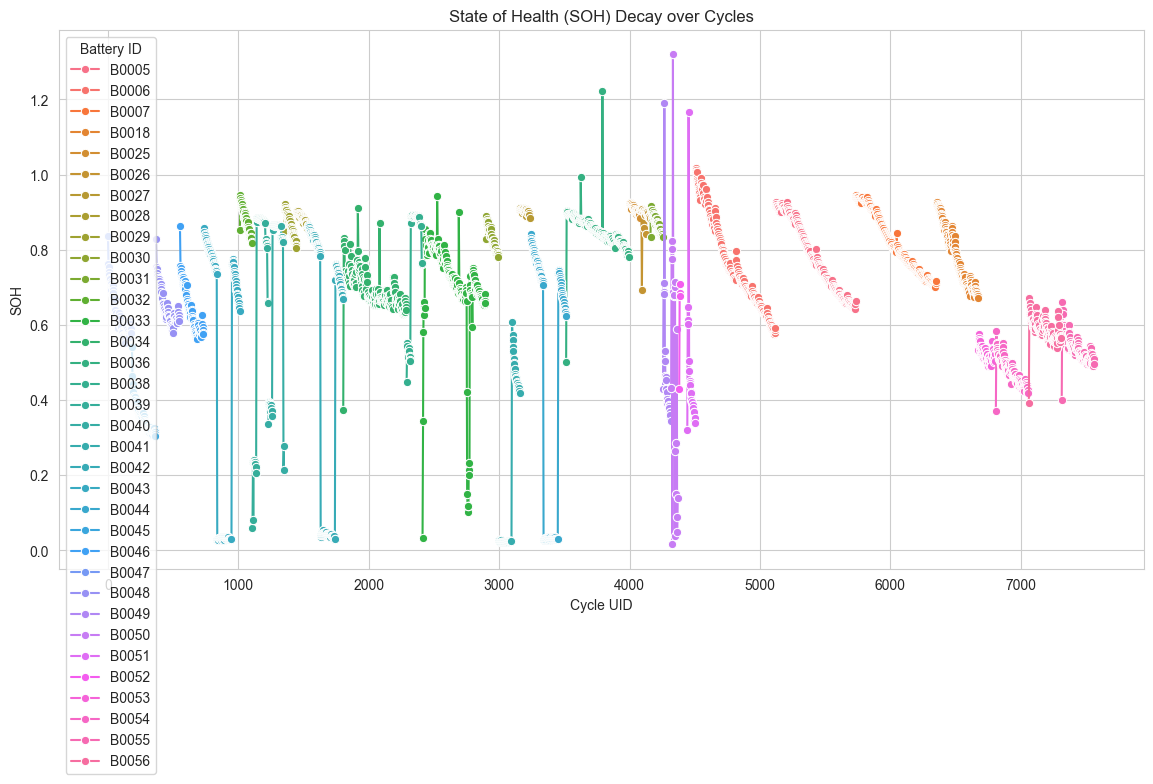

In [18]:
# Plot SOH vs Cycle Number (approximated by index/uid sequence) for each battery
plt.figure(figsize=(14, 7))
sns.lineplot(data=soh_table, x='uid', y='SOH', hue='battery_id', marker='o')
plt.title('State of Health (SOH) Decay over Cycles')
plt.xlabel('Cycle UID')
plt.ylabel('SOH')
plt.legend(title='Battery ID')
plt.show()

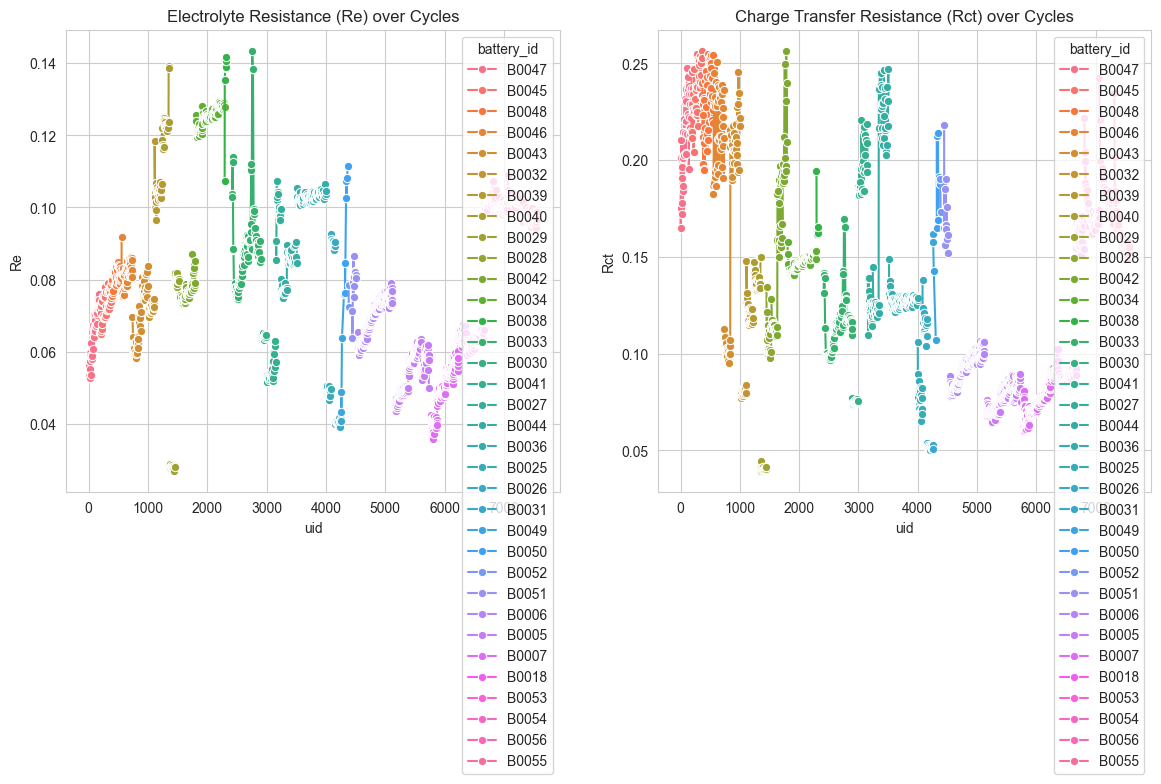

In [15]:
# Plot Re and Rct evolution for each battery
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.lineplot(data=impedance_final, x='uid', y='Re', hue='battery_id', marker='o')
plt.title('Electrolyte Resistance (Re) over Cycles')

plt.subplot(1, 2, 2)
sns.lineplot(data=impedance_final, x='uid', y='Rct', hue='battery_id', marker='o')
plt.title('Charge Transfer Resistance (Rct) over Cycles')
plt.show()

In [16]:
# Saving cleaned datasets
impedance_final.to_csv(impedance_final_path, index=False)
soh_table.to_csv(soh_table_path, index=False)

print("Saved 'cleaned_impedance_metadata.csv' and 'soh_calculations.csv' to data directory.")

Saved 'cleaned_impedance_metadata.csv' and 'soh_calculations.csv' to data directory.
